In [6]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO

In [8]:
START_YEAR = 1891
END_YEAR = 2025

OUTPUT_DAILY = "../data/processed/cyclone_daily_1891_2025.csv"
OUTPUT_YEARLY = "../data/processed/cyclone_yearly_1891_2025.csv"

# Bay of Bengal bounding box
LAT_MIN = 5
LAT_MAX = 25
LON_MIN = 80
LON_MAX = 100

In [9]:
df = pd.read_csv("../data/raw/ibtracs.ALL.list.v04r00 (1).csv")

print("Raw dataset shape:", df.shape)

C:\Users\SAMADRITA KARMAKAR\AppData\Local\Temp\ipykernel_20444\3221591679.py:1: DtypeWarning: Columns (1,2,8,9,14,19,20,161,162) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/ibtracs.ALL.list.v04r00 (1).csv")


Raw dataset shape: (716166, 163)


In [11]:
columns = df.columns
print("Columns in the dataset:", columns)

Columns in the dataset: Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON',
       ...
       'BOM_GUST_PER', 'REUNION_GUST', 'REUNION_GUST_PER', 'USA_SEAHGT',
       'USA_SEARAD_NE', 'USA_SEARAD_SE', 'USA_SEARAD_SW', 'USA_SEARAD_NW',
       'STORM_SPEED', 'STORM_DIR'],
      dtype='object', length=163)


In [12]:
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce")

df["YEAR"] = df["ISO_TIME"].dt.year
df["MONTH"] = df["ISO_TIME"].dt.month
df["DAY"] = df["ISO_TIME"].dt.day

C:\Users\SAMADRITA KARMAKAR\AppData\Local\Temp\ipykernel_20444\2730514673.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce")


In [13]:
df.head

<bound method NDFrame.head of                   SID SEASON NUMBER BASIN SUBBASIN       NAME  \
0                       Year                                    
1       1842298N11080   1842      1    NI       BB  NOT_NAMED   
2       1842298N11080   1842      1    NI       BB  NOT_NAMED   
3       1842298N11080   1842      1    NI       BB  NOT_NAMED   
4       1842298N11080   1842      1    NI       BB  NOT_NAMED   
...               ...    ...    ...   ...      ...        ...   
716161  2024147N19089   2024     27    NI       BB      REMAL   
716162  2024147N19089   2024     27    NI       BB      REMAL   
716163  2024147N19089   2024     27    NI       BB      REMAL   
716164  2024147N19089   2024     27    NI       BB      REMAL   
716165  2024147N19089   2024     27    NI       BB      REMAL   

                  ISO_TIME NATURE            LAT           LON  ...  \
0                      NaT         degrees_north  degrees_east  ...   
1      1842-10-25 03:00:00     NR        10.900

In [15]:
df = df[(df["YEAR"] >= START_YEAR) & (df["YEAR"] <= END_YEAR)]

In [16]:

df = df[df["BASIN"] == "NI"]  # North Indian Ocean

In [17]:
df.shape

(50497, 166)

In [18]:
df["WIND"] = pd.to_numeric(df["USA_WIND"], errors="coerce")

# Severe cyclone threshold
df["SEVERE"] = df["WIND"] >= 64  # knots

df["sea_region"] = np.where(df["LON"] > 80, "bob", "arabian")

In [20]:
daily = df.groupby(["YEAR", "MONTH", "DAY"]).agg(
    cyclones_total=("SID", "nunique"),
    max_wind=("WIND", "max"),
    severe_total=("SEVERE", "sum")
)

daily = daily.reset_index()

# approximate disturbances
daily["disturbances_total"] = daily["cyclones_total"] * 2

# engineered features
daily["severity_ratio"] = (
    daily["severe_total"] / (daily["cyclones_total"] + 1)
)

daily["disturbance_ratio"] = (
    daily["disturbances_total"] / (daily["cyclones_total"] + 1)
)

daily["target"] = (daily["severe_total"] > 0).astype(int)

# rolling climate trend (5 year = 1825 days approx)
daily["cyclone_5yr_avg"] = (
    daily["cyclones_total"]
    .rolling(window=1825, min_periods=1)
    .mean()
)

In [21]:
yearly = daily.groupby("YEAR").agg(
    cyclones_total=("cyclones_total", "sum"),
    disturbances_total=("disturbances_total", "sum"),
    severe_total=("severe_total", "sum")
)

yearly = yearly.reset_index()

yearly["severity_ratio"] = (
    yearly["severe_total"] / (yearly["cyclones_total"] + 1)
)

yearly["disturbance_ratio"] = (
    yearly["disturbances_total"] / (yearly["cyclones_total"] + 1)
)

yearly["target"] = (yearly["severe_total"] > 0).astype(int)

yearly["cyclone_5yr_avg"] = (
    yearly["cyclones_total"]
    .rolling(window=5, min_periods=1)
    .mean()
)

In [22]:
full_days = pd.date_range(start=f"{START_YEAR}-01-01", end=f"{END_YEAR}-12-31", freq='D')
full_days = pd.DataFrame({"DATE": full_days})
full_days["YEAR"] = full_days["DATE"].dt.year
full_days["MONTH"] = full_days["DATE"].dt.month
full_days["DAY"] = full_days["DATE"].dt.day

In [23]:
daily = full_days.merge(
    daily,
    on=["YEAR", "MONTH", "DAY"],
    how="left"
)

In [24]:
daily["cyclones_total"] = daily["cyclones_total"].fillna(0)
daily["severe_total"] = daily["severe_total"].fillna(0)
daily["max_wind"] = daily["max_wind"].fillna(0)
daily["disturbances_total"] = daily["disturbances_total"].fillna(0)

In [25]:
daily["severity_ratio"] = (
    daily["severe_total"] / (daily["cyclones_total"] + 1)
)

daily["disturbance_ratio"] = (
    daily["disturbances_total"] / (daily["cyclones_total"] + 1)
)

daily["target"] = (daily["severe_total"] > 0).astype(int)

In [26]:
daily["target"].value_counts()

target
0    49035
1      273
Name: count, dtype: int64

In [28]:
daily["season"] = daily["MONTH"].map({
    1:"winter",
    2:"winter",
    3:"pre_monsoon",
    4:"pre_monsoon",
    5:"pre_monsoon",
    6:"monsoon",
    7:"monsoon",
    8:"monsoon",
    9:"post_monsoon",
    10:"post_monsoon",
    11:"post_monsoon",
    12:"winter"
})

In [29]:
daily[daily["target"] == 1].head()

,DATE,YEAR,MONTH,DAY,cyclones_total,max_wind,severe_total,disturbances_total,severity_ratio,disturbance_ratio,target,cyclone_5yr_avg,season
29683,1972-04-09,1972,4,9,1.0,85.0,6.0,2.0,3.0,1.0,1,1.103014,pre_monsoon
29836,1972-09-09,1972,9,9,1.0,80.0,7.0,2.0,3.5,1.0,1,1.101918,post_monsoon
29837,1972-09-10,1972,9,10,1.0,75.0,1.0,2.0,0.5,1.0,1,1.101918,post_monsoon
29848,1972-09-21,1972,9,21,1.0,70.0,6.0,2.0,3.0,1.0,1,1.101918,post_monsoon
29849,1972-09-22,1972,9,22,1.0,65.0,1.0,2.0,0.5,1.0,1,1.101918,post_monsoon


In [30]:
daily.groupby("MONTH")["target"].sum()

MONTH
1      0
2      0
3      0
4     14
5     68
6     30
7      0
8      0
9      8
10    41
11    90
12    22
Name: target, dtype: int64

In [31]:
daily = pd.get_dummies(daily, columns=["season"])

In [ ]:
#cyclone history considered as the previous day and today
daily["cyclones_prev_day"] = daily["cyclones_total"].shift(1)
#cyclone hisrtory considered as the previous 3 days and today
daily["cyclones_prev_3d"] = daily["cyclones_total"].rolling(3).mean()

daily["cyclones_prev_7d"] = daily["cyclones_total"].rolling(7).mean()

<Axes: xlabel='MONTH', ylabel='count'>

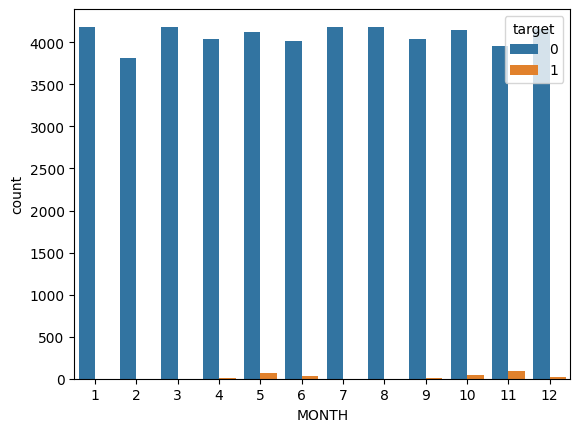

In [33]:
import seaborn as sns

sns.countplot(x="MONTH", hue="target", data=daily)

In [35]:
daily.to_csv(OUTPUT_DAILY, index=False)
yearly.to_csv(OUTPUT_YEARLY, index=False)

print("Saved daily dataset:", OUTPUT_DAILY)
print("Saved yearly dataset:", OUTPUT_YEARLY)

print("Daily rows:", len(daily))
print("Yearly rows:", len(yearly))

Saved daily dataset: ../data/processed/cyclone_daily_1891_2025.csv
Saved yearly dataset: ../data/processed/cyclone_yearly_1891_2025.csv
Daily rows: 49308
Yearly rows: 134
